In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.dates as mdates

In [5]:
data_path = "dataset/"
files = {}
for f in os.listdir(data_path):
    name = f.replace(".csv", "")
    files[name] = pd.read_csv(data_path + f)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13984\1167941810.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  files[name] = pd.read_csv(data_path + f)


In [16]:
sales = files['sales']
x_sales = pd.to_datetime(sales['Date'])
y_sales = sales['Revenue']

In [17]:
promotions = files['promotions']
x_promotions_start = pd.to_datetime(promotions['start_date'])
x_duration = pd.to_datetime(promotions['end_date']) - x_promotions_start
y_promotions = promotions['discount_value']

In [50]:
orders = files['orders']

In [59]:
# 1. Ensure the date column is in datetime format
orders['order_date'] = pd.to_datetime(orders['order_date'])

# 2. Group by date and count the number of rows (orders) per day
# .size() counts the rows, .sort_index() ensures the dates are in order
order_summary = orders.groupby('order_date').size().sort_index()

# 3. Retrieve your x and y variables
x_order_counts = order_summary.index
y_order_counts = order_summary.values

# Optional: Print the first few to verify
print("Dates (x):", x_order_counts[:5])
print("Counts (y):", y_order_counts[:5])

Dates (x): DatetimeIndex(['2012-07-04', '2012-07-05', '2012-07-06', '2012-07-07',
               '2012-07-08'],
              dtype='datetime64[ns]', name='order_date', freq=None)
Counts (y): [162  97  93  73  88]


In [60]:
y_order_counts

array([162,  97,  93, ..., 143, 106,  74], shape=(3833,))

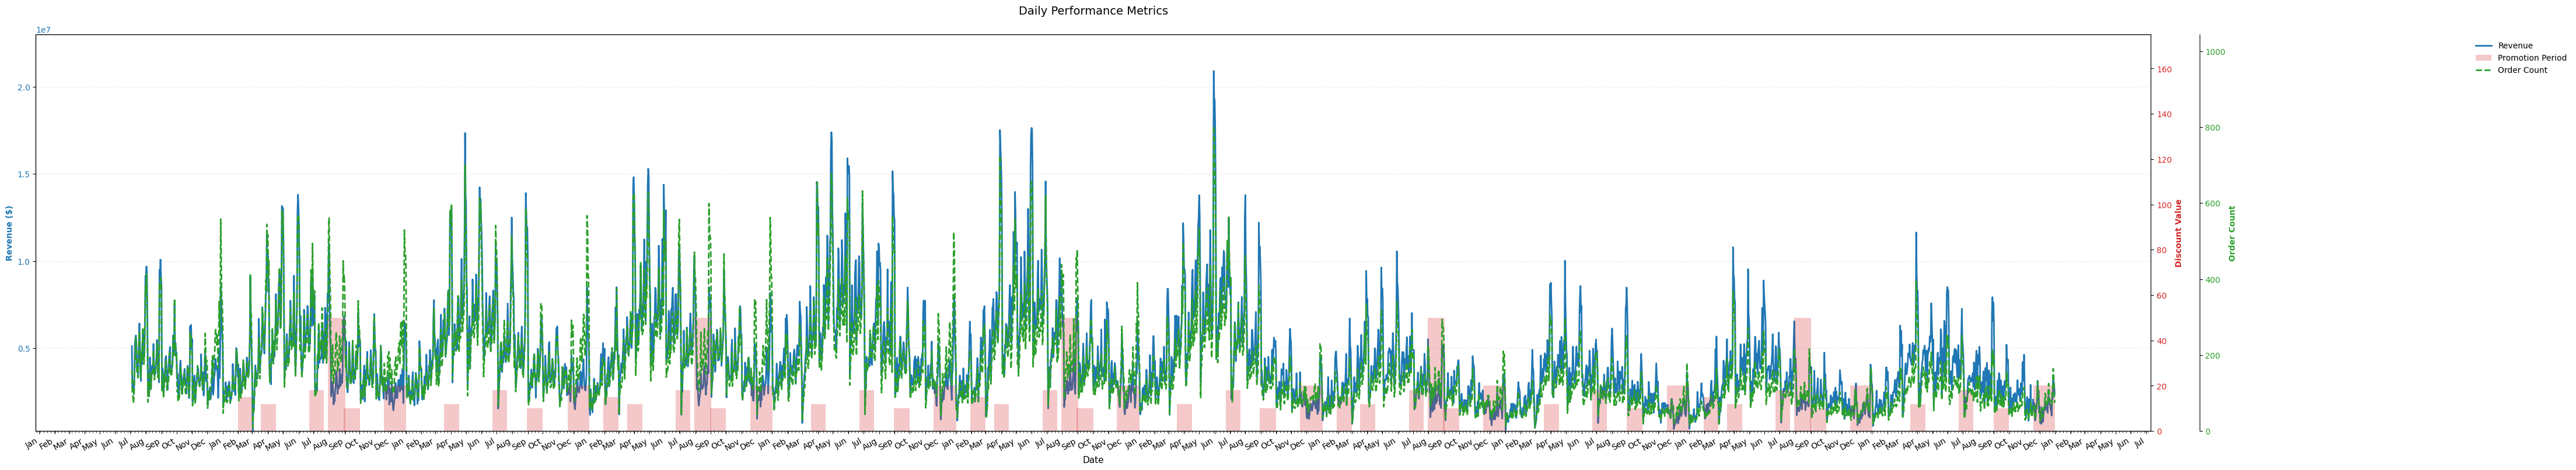

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Data Preparation for Orders ---
orders['order_date'] = pd.to_datetime(orders['order_date'])
order_summary = orders.groupby('order_date').size().sort_index()

x_order_counts = order_summary.index
y_order_counts = order_summary.values

# --- Graphing Section ---
fig, ax1 = plt.subplots(figsize=(30, 10))
# Adjust right margin to make room for the third axis labels
plt.subplots_adjust(right=0.85)

# 1. Revenue (Primary Axis - Left)
color_rev = '#1f77b4' # Muted Blue
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Revenue ($)', color=color_rev, fontweight='bold')
line1 = ax1.plot(x_sales, y_sales, color=color_rev, linewidth=2, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color_rev)

# 2. Promotions (Secondary Axis - Right)
ax2 = ax1.twinx()
color_prom = '#d62728' # Muted Red
ax2.set_ylabel('Discount Value', color=color_prom, fontweight='bold')
duration_days = (pd.to_datetime(promotions['end_date']) - pd.to_datetime(promotions['start_date'])).dt.days
bars = ax2.bar(pd.to_datetime(promotions['start_date']), promotions['discount_value'], 
               width=duration_days, align='edge', 
               color=color_prom, alpha=0.25, label='Promotion Period')
ax2.tick_params(axis='y', labelcolor=color_prom)

# 3. Order Count (Third Axis - Offset Right)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60)) 
color_count = '#2ca02c' # Muted Green
ax3.set_ylabel('Order Count', color=color_count, fontweight='bold')
# Using linestyle='--' instead of markers to distinguish from Revenue
line3 = ax3.plot(x_order_counts, y_order_counts, color=color_count, 
                 linewidth=2, linestyle='--', label='Order Count')
ax3.tick_params(axis='y', labelcolor=color_count)

# --- Spacing & Scale Fixes ---
# These limits prevent the lines from overlapping awkwardly
ax1.set_ylim(bottom=y_sales.min() * 0.9, top=y_sales.max() * 1.1)
ax2.set_ylim(0, promotions['discount_value'].max() * 3.5)
ax3.set_ylim(0, y_order_counts.max() * 1.3)

# --- Legend & Labels ---
lines_all = line1 + [bars] + line3
labels_all = [l.get_label() for l in lines_all]
ax1.legend(lines_all, labels_all, loc='upper left', bbox_to_anchor=(1.15, 1), frameon=False)

plt.title('Daily Performance Metrics', pad=25, fontsize=14)
ax1.grid(True, axis='y', linestyle=':', alpha=0.4) # Grid only on the horizontal for clarity
fig.autofmt_xdate()

# 1. Set the locator (e.g., every month)
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# 2. Set the format (e.g., 'Jan 2012' or just 'Jan')
# Use '%b %Y' for 'Jan 2012' or '%B' for the full month name
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# 3. Optional: Add minor ticks for weeks if the month feels too empty
ax1.xaxis.set_minor_locator(mdates.WeekdayLocator())

# Ensure dates are tilted for readability
fig.autofmt_xdate()

plt.show()